# TableTalk: Premier League results

Everything the Premier League model produces, in one place:

1. **Current predictions** and **team ratings** for the season in progress.
2. **How the settings were chosen**: on the tuning seasons only.
3. **Match-level backtest** on the report seasons, with calibration.
4. **Season-level backtest** on the report seasons.
5. **Promoted teams**: the three strategies compared.
6. **The betting market**: how close the model gets to closing odds.
7. **Points deductions**: the official 2023-24 table rebuilt.

**Tune and report seasons.** Every setting was chosen on the six *tuning* seasons (2012-13 to 2017-18). Every headline result comes from the six *report* seasons (2018-19, 2021-22 to 2025-26), which were never used to choose anything. The two COVID seasons are left out of both. The protocol, written before anything was run, is in `reports/protocols/a1-clean-split.md`.

**How results are worded.** Comparisons are paired (scored on the same matches) and quoted as a difference ± a 95% interval, about two standard errors. When the interval includes zero, or a result holds in one half of the data but not the other, it is called "consistently better but modest" or "no detectable difference", never "beats".

Slow results are cached in `data/processed/` (`pl_*.pkl`); delete them to recompute. The command-line equivalents: `python -m tabletalk simulate | ratings | tune | evaluate | evaluate-seasons | benchmark`.

In [1]:
import warnings

import numpy as np
import pandas as pd

from tabletalk.config import load_competition
from tabletalk.data import load_context_matches, load_matches
from tabletalk.data.deductions import load_points_deductions
from tabletalk.evaluation.backtest import paired_comparison, per_match_log_loss, summarise_backtest, summarise_by_season
from tabletalk.evaluation.calibration import calibration_table, expected_calibration_error, match_calibration
from tabletalk.evaluation.market import MARKET, add_market_forecasts, gap_closed, load_market_odds, odds_coverage
from tabletalk.evaluation.plots import plot_calibration, plot_zone_probabilities
from tabletalk.evaluation.season_backtest import (
    favourite_record, pooled_zone_log_loss, season_backtest, season_calibration_by_phase,
)
from tabletalk.evaluation.tuning import tune_match_model
from tabletalk.evaluation.backtest import match_backtest
from tabletalk.model.promoted import fit_competition_model, promoted_teams
from tabletalk.paths import PROCESSED_DATA_DIR
from tabletalk.simulation import league_table, simulate_league

warnings.simplefilter('ignore', UserWarning)  # rho-bound notices on tiny early-season fits
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)

config = load_competition('premier_league')
matches = load_matches(config)
context = load_context_matches(config)   # Championship results, for the model only
TUNE, REPORT = (list(config.evaluation_split[name]) for name in ('tune', 'report'))

def cached(name, compute):
    """Load a slow result from data/processed/, computing and saving it the first time."""
    path = PROCESSED_DATA_DIR / f'{name}.pkl'
    if path.exists():
        return pd.read_pickle(path)
    value = compute()
    pd.to_pickle(value, path)
    return value

def as_percent(frame, columns):
    return frame.assign(**{c: (100 * frame[c]).round(1) for c in columns})

print(f'{config.name}: {len(matches):,} matches loaded, current season {config.current_season}')
print('tuning seasons:', ', '.join(TUNE))
print('report seasons:', ', '.join(REPORT))

Premier League: 6,460 matches loaded, current season 2026-27
tuning seasons: 2012-13, 2013-14, 2014-15, 2015-16, 2016-17, 2017-18
report seasons: 2018-19, 2021-22, 2022-23, 2023-24, 2024-25, 2025-26


## 1. Current predictions

The rest of the season, simulated 10,000 times. Teams are ordered by expected finishing position; probabilities are in %. Each figure carries about ±1 percentage point of simulation noise at 50%, less near 0 or 100.

In [2]:
result = simulate_league(config, matches, context)
summary = result.summary()
zone_ids = [zone.id for zone in config.zones]
as_percent(summary, zone_ids)[
    ['position_now', 'points_now', 'expected_points', 'points_p10', 'points_p90', *zone_ids]
].round(1)

,position_now,points_now,expected_points,points_p10,points_p90,title,top_four,top_five,top_half,relegation
team,,,,,,,,,,
Manchester City,1,15,82.2,71.0,93.0,58.1,98.0,99.1,100.0,0.0
Arsenal,2,12,78.6,68.0,89.0,34.6,95.5,97.5,99.9,0.0
Liverpool,6,9,66.7,56.0,78.0,4.1,62.5,73.8,96.2,0.0
Brighton & Hove Albion,3,10,61.1,50.0,72.0,1.3,36.9,50.1,87.8,0.3
Brentford,4,9,57.5,47.0,69.0,0.5,21.0,32.9,77.4,0.8
Chelsea,10,7,56.6,46.0,68.0,0.3,18.2,28.4,72.9,1.0
Newcastle United,9,8,56.4,45.0,68.0,0.4,17.6,28.0,72.1,1.2
Manchester United,12,5,54.1,43.0,66.0,0.2,12.7,20.5,63.4,2.1
Leeds United,5,9,52.4,41.0,65.0,0.2,9.9,16.5,54.4,4.0


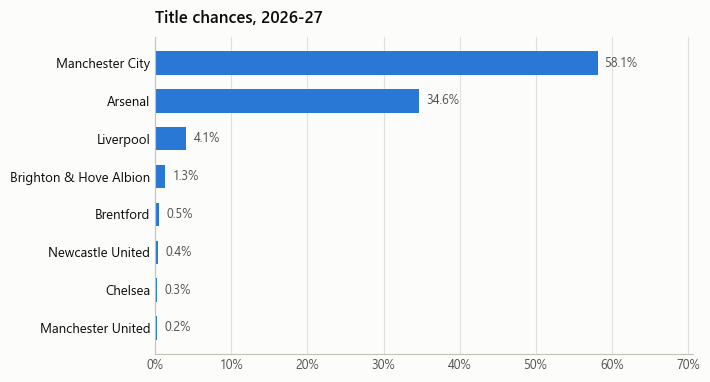

In [3]:
plot_zone_probabilities(summary, 'title', title=f'Title chances, {config.current_season}', top=8);

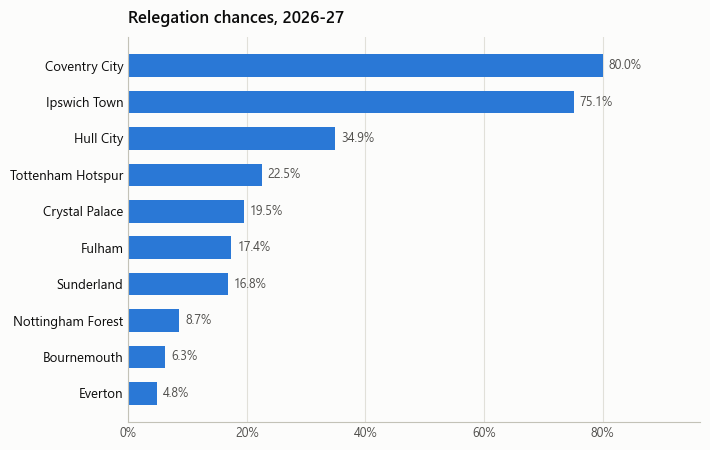

In [4]:
plot_zone_probabilities(summary, 'relegation', title=f'Relegation chances, {config.current_season}', top=10);

**Reading the average table.** `expected_points` is an average over 10,000 seasons, and averaging pulls everyone toward the middle: in any single simulated season *someone* runs hot, but it is a different team each time. The 10th-90th percentile range (`points_p10`, `points_p90`) is the better guide to realistic totals.

### Team ratings

Each team's attack and defence on a log scale, re-centred on this season's league average. `attack_x` reads as "scores this many times an average team's goals", `concede_x` as "concedes this many times". The promoted teams start from the promoted-team prior and have only a handful of matches of their own.

In [5]:
fit = fit_competition_model(config, matches, context)
ratings = fit.model.ratings(sorted(result.teams))
ratings['attack'] -= ratings['attack'].mean()
ratings['defence'] -= ratings['defence'].mean()
ratings = ratings.assign(
    net=ratings['attack'] + ratings['defence'],
    attack_x=np.exp(ratings['attack']),
    concede_x=np.exp(-ratings['defence']),
).sort_values('net', ascending=False).reset_index(drop=True)
ratings.index += 1
print(fit.model.summary())
print('promoted this season:', ', '.join(fit.promoted))
ratings[['team', 'attack', 'defence', 'net', 'attack_x', 'concede_x', 'matches']].round(3)

Dixon-Coles fit as of 2026-09-21 (365-day half-life): 3780 matches (519 effective), 35 teams
  average team scores away : 1.192 goals
  home advantage           : +0.169 (x1.184 goals at home)
  rho (low-score coupling) : -0.0839
  division offsets         : none
  converged                : True (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)
promoted this season: Coventry City, Hull City, Ipswich Town


,team,attack,defence,net,attack_x,concede_x,matches
1,Arsenal,0.280,0.493,0.772,1.322,0.611,378
2,Manchester City,0.412,0.330,0.742,1.509,0.719,378
3,Liverpool,0.290,0.113,0.403,1.337,0.894,378
4,Brighton & Hove Albion,0.157,0.027,0.184,1.170,0.974,347
5,Manchester United,0.129,-0.001,0.128,1.138,1.001,378
6,Chelsea,0.156,-0.040,0.116,1.168,1.041,378
7,Brentford,0.115,0.000,0.115,1.122,1.000,195
8,Newcastle United,0.161,-0.054,0.107,1.175,1.055,347
9,Aston Villa,0.066,-0.009,0.057,1.068,1.009,271
10,Bournemouth,0.045,-0.023,0.022,1.046,1.023,302


## 2. How the settings were chosen

The half-life (how fast old matches are forgotten) and the ridge prior sd (how strongly ratings are pulled toward average) were chosen by a grid search on the **tuning seasons only**, with the rule written down beforehand: lowest log loss wins. `diff_vs_best` is each setting's log loss minus the winner's on the same matches, ± a 95% interval.

In [6]:
grid = cached('pl_tune_grid', lambda: tune_match_model(
    config, matches, context, TUNE, half_lives=[60, 90, 120, 180, 270, 365, 540], prior_sds=[0.5, 1.0, 2.0]))
grid.round(5).head(10)

,half_life_days,rating_prior_sd,n,log_loss,diff_vs_best,ci95
0,365.0,1.0,2280,0.97013,0.00000,0.00000
1,270.0,1.0,2280,0.97027,0.00014,0.00110
2,365.0,2.0,2280,0.97044,0.00031,0.00053
3,365.0,0.5,2280,0.97051,0.00039,0.00079
4,540.0,1.0,2280,0.97062,0.00050,0.00113
5,270.0,2.0,2280,0.97064,0.00051,0.00132
6,270.0,0.5,2280,0.97074,0.00061,0.00122
7,540.0,0.5,2280,0.97089,0.00076,0.00141
8,540.0,2.0,2280,0.97091,0.00079,0.00122
9,180.0,1.0,2280,0.97188,0.00176,0.00286


365 days wins, but the surface is flat from 270 to 540 days (all within 0.0008, well inside the noise); below 120 days is clearly worse. Phase 1's 180 days was 0.0018 ± 0.0029 behind. The ridge sd barely matters. On the report seasons the switch from 180 to 365 days makes no measurable difference (+0.0006 ± 0.0033), so this is a clean-up of *how* the value was chosen more than a change in accuracy.

The promoted-team strategy and the simulation's uncertainty were chosen on the tuning seasons the same way (sections 4 and 5).

## 3. Match-level backtest (report seasons)

For every week of the report seasons, fit the model on results *before* that week and forecast the week's matches. No forecast ever sees its own future. The baseline predicts the league's historical home/draw/away frequencies for every match. Lower is better for all three scores.

In [7]:
match_report = cached('pl_match_report', lambda: match_backtest(config, matches, context, REPORT))
backtest_summary = summarise_backtest(match_report)
backtest_summary.loc[backtest_summary['group'] == 'all matches'].round(4)

,group,model,n,log_loss,brier,rps,vs_baseline_pct
0,all matches,prior,2280,0.9647,0.5727,0.1988,9.3649
1,all matches,second_tier,2280,0.9677,0.5745,0.1997,9.0807
2,all matches,none,2280,0.9653,0.5727,0.1989,9.3117
3,all matches,baseline,2280,1.0644,0.6437,0.2331,0.0000


In [8]:
summarise_by_season(match_report).round(4)

model,baseline,none,prior,second_tier
season,,,,
2018-19,1.0459,0.8946,0.8981,0.8970
2021-22,1.0712,0.9524,0.9495,0.9495
2022-23,1.0496,1.0019,0.9982,0.9918
2023-24,1.0552,0.9250,0.9240,0.9289
2024-25,1.0821,0.9896,0.9880,0.9997
2025-26,1.0823,1.0280,1.0304,1.0396


### Calibration

Forecasts grouped by the probability they gave, against how often the outcome happened. On the diagonal is well calibrated; the vertical lines are 95% intervals. The panels underneath show how many forecasts fell in each range.

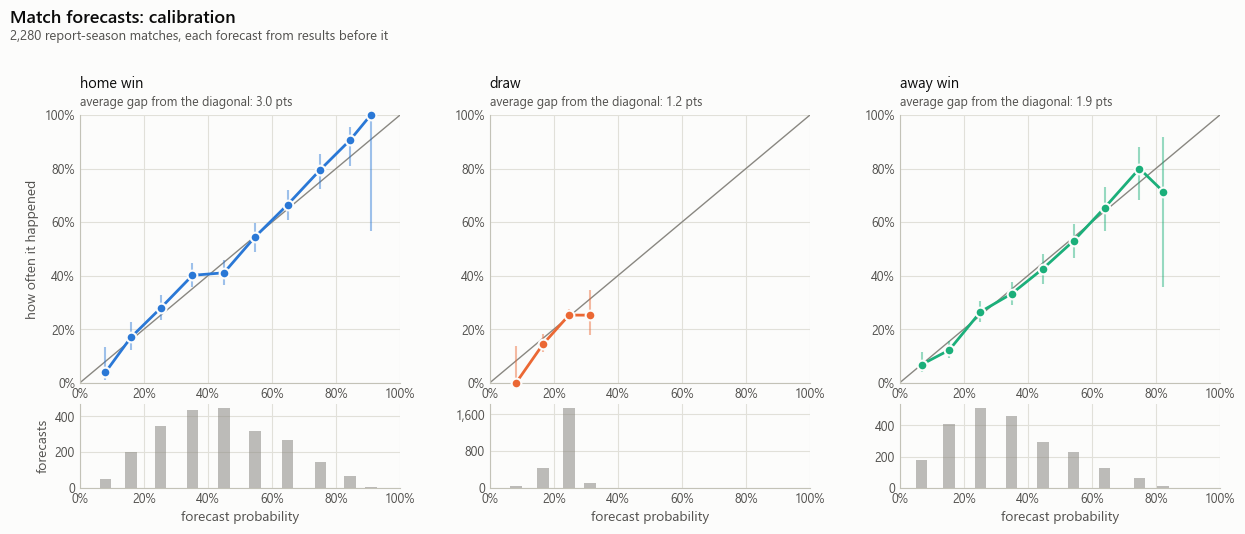

In [9]:
model_rows = match_report.loc[match_report['model'] == 'prior']
tables = match_calibration(model_rows)
plot_calibration(
    {'home win': tables['home'], 'draw': tables['draw'], 'away win': tables['away']},
    title='Match forecasts: calibration',
    subtitle=f'{len(model_rows):,} report-season matches, each forecast from results before it',
);

In [10]:
{outcome: round(100 * expected_calibration_error(table), 1) for outcome, table in tables.items()}

{'home': 3.0, 'draw': 1.2, 'away': 1.9}

Average gaps from the diagonal of a few percentage points; the home-win bins that miss are mostly still inside their 95% intervals, and with six seasons each bin holds half as many matches as in Phase 1.

The one thing the model cannot do is **pick out draws**: almost every draw forecast lies between 20% and 30%. Section 6 shows the betting market's draw forecasts barely vary more, so this is mostly a property of football rather than of Dixon-Coles.

## 4. Season-level backtest (report seasons)

The question the project exists for. Each report season is replayed from four checkpoints (pre-season, then after 25%, 50% and 75% of the matches): every later result, and every later points deduction, is forgotten; the model is fitted on what was known then, and the rest of the season is simulated 5,000 times. Zone forecasts are scored against the real final table and two baselines:

- **uniform** knows nothing: a 1-in-20 title chance for everyone, 4-in-20 for the top four, and so on.
- **persistence** says the table as it stands will be the final table (pre-season: last season's table, promoted teams at the bottom). The naive pundit, and a hard baseline late in a season.

Six seasons means six titles and 18 relegations, so single cells move a lot with one season's surprises; they are described, not declared won.

In [11]:
seasons_report = cached('pl_season_report', lambda: season_backtest(config, matches, context, REPORT, n_simulations=5_000))
zones = seasons_report.zone_summary()
order = zones['checkpoint'].unique()
skill = {
    baseline: zones.pivot(index='checkpoint', columns='zone', values=f'skill_vs_{baseline}_pct').loc[order, zone_ids]
    for baseline in ('uniform', 'persistence')
}
print('Brier-score skill vs uniform (% better; higher is better)')
skill['uniform'].round(1)

Brier-score skill vs uniform (% better; higher is better)


zone,title,top_four,top_five,top_half,relegation
checkpoint,,,,,
pre-season,54.4,43.7,56.0,34.9,29.3
25% played,66.6,57.4,66.4,50.5,54.8
50% played,65.8,77.9,85.3,65.7,65.9
75% played,67.4,76.8,85.3,70.3,79.7


In [12]:
print('Brier-score skill vs persistence (% better than "the table as it stands")')
skill['persistence'].round(1)

Brier-score skill vs persistence (% better than "the table as it stands")


zone,title,top_four,top_five,top_half,relegation
checkpoint,,,,,
pre-season,35.0,46.0,55.0,42.6,22.8
25% played,76.2,54.5,52.8,32.5,30.9
50% played,67.5,29.2,58.6,14.1,34.9
75% played,69.0,44.3,58.6,44.3,22.5


In [13]:
print('Finishing position: ranked probability score (lower is better) and average error in places')
seasons_report.position_summary().round(3)

Finishing position: ranked probability score (lower is better) and average error in places


,checkpoint,n,rps_model,rps_uniform,rps_persistence,position_error_model,position_error_persistence
0,pre-season,120,0.110,0.175,0.169,3.041,3.217
1,25% played,120,0.084,0.175,0.132,2.299,2.500
2,50% played,120,0.059,0.175,0.093,1.589,1.767
3,75% played,120,0.046,0.175,0.075,1.286,1.433


In [14]:
print("How often the model's title favourite won (descriptive only)")
favourite_record(seasons_report.zones).round(3)

How often the model's title favourite won (descriptive only)


,checkpoint,seasons,favourite_won,mean_favourite_probability
0,pre-season,6,4,0.629
1,25% played,6,5,0.681
2,50% played,6,5,0.686
3,75% played,6,5,0.638


**Relegation at 75% played** is the cell to read carefully. In 4 of the 6 report seasons the bottom three with a quarter of the season left was the final bottom three, and there "the table as it stands" is perfect: the model, holding on to ratings, can only lose (Leicester 2022-23 were given about 20% and went down). Pooled, the model is ahead only because persistence got 2023-24 wrong: Nottingham Forest were in the bottom three after their points deduction and survived. Ratings lag a genuinely declining team; that problem is real and is the next model change to make.

### Rating uncertainty: chosen on the tuning seasons

A simulator that uses today's best-estimate ratings for every simulated season ignores how unsure those ratings are, and that uncertainty is shared by every remaining match a team plays. Three versions were compared on the **tuning seasons**, with the rule set in advance (lowest pooled zone log loss): fixed strengths, ratings drawn from the fit's uncertainty (the Laplace approximation), and that plus drift through the season.

In [15]:
variants = {
    'fixed strengths': cached('pl_season_tune_fixed', lambda: season_backtest(
        config, matches, context, TUNE, fixed_strengths=True).zones),
    'rating uncertainty (chosen)': cached('pl_season_tune_parameter', lambda: season_backtest(
        config, matches, context, TUNE,
        strength_uncertainty={'enabled': True, 'parameter_uncertainty': True, 'drift': 'none'}).zones),
    '+ drift': cached('pl_season_tune_parameter_drift', lambda: season_backtest(
        config, matches, context, TUNE,
        strength_uncertainty={'enabled': True, 'parameter_uncertainty': True, 'drift': 'implied'}).zones),
}

def confident(zones):
    rows = zones.loc[zones['p_model'].between(0.7, 0.99)]
    return 100 * rows.groupby('checkpoint', sort=False)[['p_model', 'outcome']].mean()

print('pooled zone log loss on the tuning seasons (lower is better):')
for name, frame in variants.items():
    print(f'  {name:<28} {pooled_zone_log_loss(frame, 5_000):.4f}')
print('\nconfident forecasts (70-99%): average forecast vs how often it happened, in %')
pd.concat({name: confident(frame) for name, frame in variants.items()}, axis=1).round(1)

pooled zone log loss on the tuning seasons (lower is better):
  fixed strengths              0.1916
  rating uncertainty (chosen)  0.1877
  + drift                      0.1879

confident forecasts (70-99%): average forecast vs how often it happened, in %


fixed strengths         rating uncertainty (chosen)         + drift        
                   p_model outcome                     p_model outcome p_model outcome
checkpoint                                                                            
pre-season            88.9    78.3                        87.3    84.6    86.8    84.6
25% played            85.5    73.3                        87.4    84.7    87.4    85.2
50% played            87.2    85.7                        86.3    86.4    86.1    86.4
75% played            88.5    93.1                        88.4    95.2    88.2    95.1

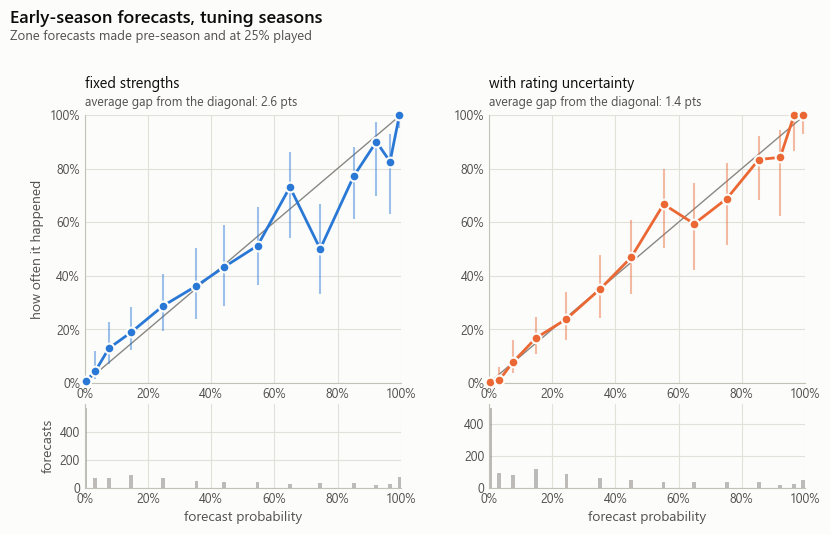

In [16]:
def early(zones):
    return next(table for name, table in season_calibration_by_phase(zones).items() if name.startswith('early'))

plot_calibration(
    {'fixed strengths': early(variants['fixed strengths']),
     'with rating uncertainty': early(variants['rating uncertainty (chosen)'])},
    title='Early-season forecasts, tuning seasons',
    subtitle='Zone forecasts made pre-season and at 25% played',
);

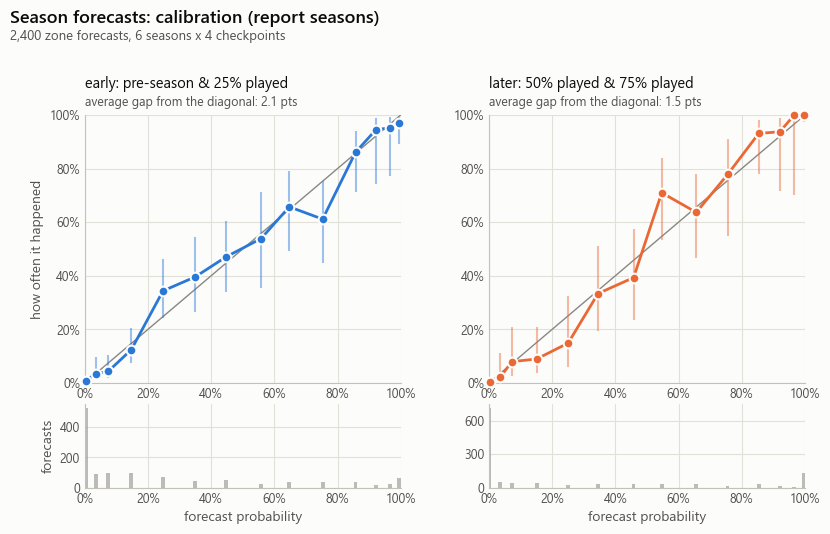

In [17]:
plot_calibration(
    season_calibration_by_phase(seasons_report.zones),
    title='Season forecasts: calibration (report seasons)',
    subtitle=f'{len(seasons_report.zones):,} zone forecasts, {len(REPORT)} seasons x 4 checkpoints',
);

With fixed strengths, confident pre-season forecasts came true noticeably less often than forecast; drawing each simulated season's ratings from the fit's uncertainty brings them close to the diagonal. Drift added nothing, so it stays off. The cost is a mild under-confidence in forecasts made mid-to-late season (the gentle S-shape above).

The pooled observations are not independent (the same team appears at four checkpoints, and exactly one team wins each title), so the intervals are narrower than they should be: read them as a guide rather than a test.

## 5. Promoted teams

Three ways to rate a team promoted this season: `prior` (start from the average first-season rating of past promoted teams), `second_tier` (fit the Championship alongside), and `none` (no special handling). `prior` was chosen on the tuning seasons (lowest log loss on promoted-team matches). Paired differences, `prior` minus each alternative, on matches involving a promoted team:

In [18]:
match_tune = cached('pl_match_tune', lambda: match_backtest(config, matches, context, TUNE))
both = pd.concat([match_tune, match_report], ignore_index=True)

def promoted_diff(frame, other):
    rows = frame.loc[frame['promoted_match'].astype(bool)]
    diff = (per_match_log_loss(rows.loc[rows['model'] == 'prior'])
            - per_match_log_loss(rows.loc[rows['model'] == other])).dropna()
    return diff

rows = []
for other in ('none', 'second_tier'):
    per_season = {season: promoted_diff(frame, other).mean() for season, frame in both.groupby('season')}
    halves = {}
    for name, frame in (('tuning seasons', match_tune), ('report seasons', match_report)):
        diff = promoted_diff(frame, other)
        halves[name] = f'{diff.mean():+.4f} ± {1.96 * diff.std(ddof=1) / np.sqrt(len(diff)):.4f}'
    rows.append({'prior minus': other, **halves,
                 'seasons where prior did better': f'{sum(v < 0 for v in per_season.values())} of {len(per_season)}'})
pd.DataFrame(rows).set_index('prior minus')

,tuning seasons,report seasons,seasons where prior did better
prior minus,,,
none,-0.0224 ± 0.0108,-0.0020 ± 0.0122,10 of 12
second_tier,-0.0097 ± 0.0103,-0.0161 ± 0.0101,10 of 12


**`prior` is consistently better but modest** against both alternatives: ahead in 10 of 12 seasons against each, by small margins, and each comparison is inside the noise in one of the two halves (against `none` on the report seasons, against `second_tier` on the tuning seasons). It should not be described as beating either.

Why `second_tier` does worse: a club is promoted partly *because* its Championship results flattered it, so a rating built from them is biased upward (the winner's curse). The bias in forecast goal difference, from the promoted team's side (positive = over-rated), on the report seasons:

In [19]:
records = []
for season in REPORT:
    promoted = set(promoted_teams(matches, config.id, season) or [])
    in_season = match_report.loc[(match_report['season'] == season) & (match_report['model'] != 'baseline')]
    for side, other in (('home', 'away'), ('away', 'home')):
        mine = in_season.loc[in_season[f'{side}_team'].isin(promoted)]
        records.append(pd.DataFrame({
            'model': mine['model'],
            'phase': np.where(mine[f'{side}_game_no'] <= 10, 'games 1-10', 'games 11-38'),
            'error': (mine[f'expected_{side}_goals'] - mine[f'expected_{other}_goals'])
                     - (mine[f'{side}_goals'].astype(float) - mine[f'{other}_goals'].astype(float)),
        }))
bias = pd.concat(records).groupby(['phase', 'model'])['error'].agg(['size', 'mean', 'sem'])
bias['ci95'] = 1.96 * bias['sem']
bias[['size', 'mean', 'ci95']].round(3)

size   mean   ci95
phase       model                          
games 1-10  none          180  0.293  0.243
            prior         180  0.218  0.240
            second_tier   180  0.434  0.244
games 11-38 none          504  0.030  0.147
            prior         504  0.002  0.147
            second_tier   504  0.142  0.147

## 6. How close does the model get to the betting market?

Bookmakers' closing odds pool every model, tipster and piece of team news up to kick-off. They are the ceiling to measure against, not something to claim to beat. The odds are Pinnacle's closing prices (low margin), falling back to the average closing odds across bookmakers where Pinnacle is missing (from 8 January 2026 on). The margin is removed by proportional normalisation, an assumption: bookmakers put more margin on long shots, so outsiders come out slightly too likely (about a point at most with Pinnacle's margin).

In [20]:
def benchmark():
    odds = load_market_odds(config)
    return add_market_forecasts(match_report.loc[match_report['model'].isin(['prior', 'baseline'])], odds)

market_report = cached('pl_benchmark_report', benchmark)
print('odds coverage and average bookmaker margin (%) per season')
odds_coverage(market_report).round(2)

odds coverage and average bookmaker margin (%) per season


,matches,AvgC,PSC,avg_margin_pct
season,,,,
2018-19,380,0,380,2.35
2021-22,380,0,380,2.45
2022-23,380,0,380,2.46
2023-24,380,0,380,2.93
2024-25,380,0,380,2.99
2025-26,380,170,210,4.29


In [21]:
overall = summarise_backtest(market_report)
overall = overall.loc[overall['group'] == 'all matches'].set_index('model')[['n', 'log_loss', 'brier', 'rps']]
base, model, market = (overall.loc[name, 'log_loss'] for name in ('baseline', 'prior', MARKET))
print(f'the model closes {100 * (base - model) / (base - market):.0f}% of the log-loss gap between knowing nothing and the market')
overall.round(4)

the model closes 83% of the log-loss gap between knowing nothing and the market


,n,log_loss,brier,rps
model,,,,
prior,2280,0.9647,0.5727,0.1988
baseline,2280,1.0644,0.6437,0.2331
market,2280,0.9449,0.5594,0.1922


In [22]:
print('per season: log loss and share of the baseline-to-market gap the model closes')
gap_closed(market_report, 'prior').round(4)

per season: log loss and share of the baseline-to-market gap the model closes


,season,n,baseline,prior,market,model_minus_market,gap_closed_pct
0,2018-19,380,1.0459,0.8981,0.8907,0.0074,95.2246
1,2021-22,380,1.0712,0.9495,0.9367,0.0128,90.4742
2,2022-23,380,1.0496,0.9982,0.9622,0.0361,58.7222
3,2023-24,380,1.0552,0.9240,0.8995,0.0244,84.3042
4,2024-25,380,1.0821,0.9880,0.9664,0.0215,81.3733
5,2025-26,380,1.0823,1.0304,1.0139,0.0165,75.8717


In [23]:
print('paired difference, model minus market (positive = market better)')
paired_comparison(market_report, 'prior', MARKET).round(4)

paired difference, model minus market (positive = market better)


,group,comparison,n,diff,ci95
0,all matches,prior - market,2280,0.0198,0.0067
1,promoted team involved,prior - market,648,0.0156,0.0122
2,early season (games 1-10),prior - market,597,0.0189,0.0124
3,"early season, promoted team involved",prior - market,169,0.0045,0.0260


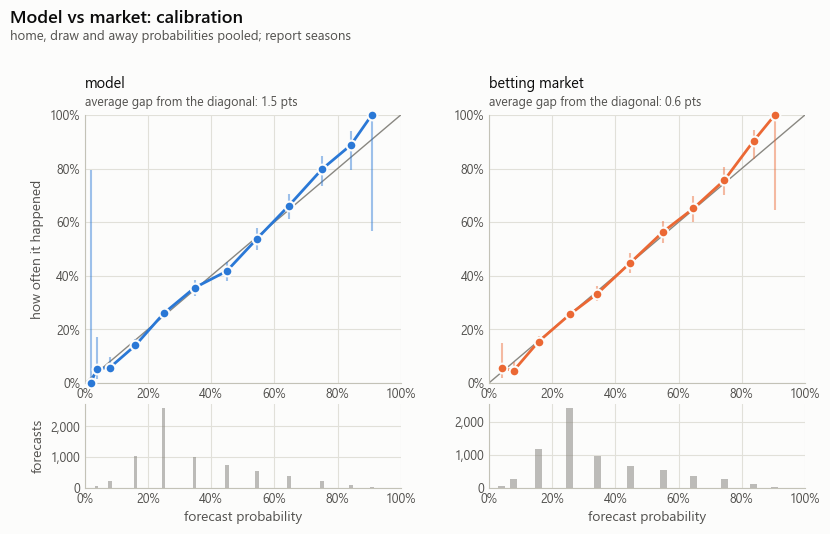

In [24]:
def pooled(rows):
    probs = rows[['p_home', 'p_draw', 'p_away']].to_numpy().ravel()
    happened = np.eye(3)[rows['outcome'].to_numpy(dtype=int)].ravel().astype(bool)
    return calibration_table(pd.Series(probs), pd.Series(happened))

plot_calibration(
    {'model': pooled(market_report.loc[market_report['model'] == 'prior']),
     'betting market': pooled(market_report.loc[market_report['model'] == MARKET])},
    title='Model vs market: calibration',
    subtitle='home, draw and away probabilities pooled; report seasons',
);

In [25]:
draws = market_report.loc[market_report['model'].isin(['prior', MARKET])].groupby('model')['p_draw']
print('draw forecasts: spread and share between 20% and 30%')
pd.DataFrame({'sd (pts)': 100 * draws.std(), 'between 20-30% (%)': 100 * draws.apply(lambda p: p.between(0.2, 0.3).mean())}).round(1)

draw forecasts: spread and share between 20% and 30%


,sd (pts),between 20-30% (%)
model,,
market,5.3,72.5
prior,4.5,76.3


The market is better, as expected: the model closes most, not all, of the gap from knowing nothing, and the per-season figures show where it falls furthest behind (2022-23, a season of fast changes in strength). Both are well calibrated; the market's edge is mostly sharpness. Part of the gap is information the model is never given: line-ups, injuries, managerial changes. And the market's draw forecasts barely vary more than the model's.

## 7. Points deductions

Deductions live in `configs/points_deductions.yaml`, one dated entry per official decision with a source link; appeals are their own entries. They change only the overall points total (head-to-head criteria count points won between the tied teams), and a replay from a date applies only decisions dated before it. With them, the rebuilt 2023-24 table matches the official final table exactly.

In [26]:
load_points_deductions()[['season', 'team', 'points', 'date_applied', 'reason']]

,season,team,points,date_applied,reason
0,2023-24,Everton,-10,2023-11-17,Breach of Profitability and Sustainability Rul...
1,2023-24,Everton,4,2024-02-26,Appeal Board reduced the 10-point deduction ab...
2,2023-24,Nottingham Forest,-4,2024-03-18,Breach of Profitability and Sustainability Rul...
3,2023-24,Everton,-2,2024-04-08,Second breach of Profitability and Sustainabil...


In [27]:
league_table(matches, config, '2023-24').set_index('position')

,team,played,won,drawn,lost,goals_for,goals_against,goal_difference,points,points_deducted
position,,,,,,,,,,
1,Manchester City,38,28,7,3,96,34,62,91,0
2,Arsenal,38,28,5,5,91,29,62,89,0
3,Liverpool,38,24,10,4,86,41,45,82,0
4,Aston Villa,38,20,8,10,76,61,15,68,0
5,Tottenham Hotspur,38,20,6,12,74,61,13,66,0
6,Chelsea,38,18,9,11,77,63,14,63,0
7,Newcastle United,38,18,6,14,85,62,23,60,0
8,Manchester United,38,18,6,14,57,58,-1,60,0
9,West Ham United,38,14,10,14,60,74,-14,52,0


Everton finish 15th on 40 (8 points deducted) and Nottingham Forest 17th on 32 (4 deducted); without the deductions Everton would be 12th. It mattered to the season backtest: on 30 March 2024 (the 75% checkpoint) the real table had Forest in the bottom three, which a table built without deductions did not show.

## Known limitations

- The model sees only scorelines: no injuries, transfers, managerial changes, xG or fixture congestion. Off-pitch pressures reach the ratings only through results.
- Future points deductions are not anticipated: a club facing an open charge is simulated as if it keeps every point.
- Ratings lag a genuinely declining team late in a season; mid-to-late season forecasts are slightly under-confident.
- Home advantage and rho are single numbers per fit; both vary from season to season.
- Six report seasons is a small sample for rare events: six champions, 18 relegations, 18 promoted teams.

The README covers each of these in more detail.